In [5]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 1738 #Trap Queen
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

#Vars
PROJECT_ROOT = Path("/ssd/SciencePrj25")
HANDPOSE_DIR = PROJECT_ROOT / "handpose"
MODELS_DIR = HANDPOSE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("TF version:", tf.__version__)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODELS_DIR:", MODELS_DIR)

# ---- GPU: enable memory growth (must be done before TF allocates GPU memory) ----
gpus = tf.config.list_physical_devices("GPU")
print("Physical GPUs:", gpus)

if gpus:
    try:
        # Memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices("GPU")
        print("Logical GPUs:", logical_gpus)
        print(f"Enabled memory growth on {len(gpus)} GPU(s).")
    except RuntimeError as e:
        # Happens if TF already initialized GPU context
        print("Could not set memory growth:", e)
else:
    print("No GPU found by TensorFlow.")


TF version: 2.16.1
PROJECT_ROOT: /ssd/SciencePrj25
MODELS_DIR: /ssd/SciencePrj25/handpose/models
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Could not set memory growth: Physical devices cannot be modified after being initialized


In [6]:
from pathlib import Path
import pandas as pd

CSV_PATH = Path("/ssd/SciencePrj25/handpose/outputs/asl_landmarks_norm.csv")

feature_cols = []
for i in range(21):
    feature_cols += [f"lm{i}_x", f"lm{i}_y", f"lm{i}_z"]

usecols = ["class_name", "handedness", "handedness_score"] + feature_cols

df = pd.read_csv(CSV_PATH, usecols=usecols, low_memory=False)

print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
display(df.head(3))

print("\nUnique classes:", df["class_name"].nunique())
display(df["class_name"].value_counts().head(10))


Loaded: /ssd/SciencePrj25/handpose/outputs/asl_landmarks_norm.csv
Shape: (151774, 66)


,class_name,handedness,handedness_score,lm0_x,lm0_y,lm0_z,lm1_x,lm1_y,lm1_z,lm2_x,...,lm17_z,lm18_x,lm18_y,lm18_z,lm19_x,lm19_y,lm19_z,lm20_x,lm20_y,lm20_z
0,A,Right,0.992514,0.450112,0.713289,-2.351324e-07,0.549816,0.670003,-0.029883,0.611860,...,-0.038578,0.418031,0.521933,-0.079722,0.428374,0.582975,-0.080497,0.437264,0.618862,-0.069918
1,A,Right,0.994529,0.349812,0.958299,-3.854434e-07,0.448490,0.922006,-0.018651,0.506380,...,-0.020155,0.320362,0.748766,-0.065757,0.325594,0.812697,-0.066480,0.334732,0.859370,-0.053873
2,A,Right,0.998036,0.420562,0.525404,-1.431865e-07,0.478434,0.522695,-0.012149,0.528146,...,-0.012808,0.438250,0.361146,-0.035346,0.432225,0.408191,-0.033896,0.427080,0.440659,-0.026270



Unique classes: 29


class_name
F    7448
K    6701
L    6572
V    6114
R    6063
W    6037
U    6017
G    6007
B    5988
D    5963
Name: count, dtype: int64

In [7]:
# Steps: Left->Right mirror (x now 1-x), wrist-center, scale by max distance from wrist

import pandas as pd

feature_cols = []
for i in range(21):
    feature_cols += [f"lm{i}_x", f"lm{i}_y", f"lm{i}_z"]

base_cols = ["class_name", "handedness", "handedness_score"]
out_rows = []

for row in df.itertuples(index=False):
    r = row._asdict()

    #Bool for left hand (to mirror x coords)
    is_left = str(r["handedness"]).lower().startswith("left")

    #Wrist Cords
    wrist_x = float(r["lm0_x"])
    wrist_y = float(r["lm0_y"])
    wrist_z = float(r["lm0_z"])
    if is_left:
        wrist_x = 1.0 - wrist_x

    #Wrist relative
    pts = []
    for i in range(21):
        x = float(r[f"lm{i}_x"])
        y = float(r[f"lm{i}_y"])
        z = float(r[f"lm{i}_z"])

        if is_left:
            x = 1.0 - x

        dx = x - wrist_x
        dy = y - wrist_y
        dz = z - wrist_z
        pts.append((dx, dy, dz))

    #Get farthest dist and use it to scale all coords to ~[-1,1]
    max_dist = 0.0
    for (dx, dy, dz) in pts:
        d = (dx*dx + dy*dy + dz*dz) ** 0.5
        if d > max_dist:
            max_dist = d

    scale = max_dist if max_dist > 1e-6 else 1.0

    #Make new row with base cols + scaled relative coords
    new_r = {
        "class_name": r["class_name"],
        "handedness": r["handedness"],
        "handedness_score": r["handedness_score"],
    }

    for i, (dx, dy, dz) in enumerate(pts):
        new_r[f"lm{i}_x"] = dx / scale
        new_r[f"lm{i}_y"] = dy / scale
        new_r[f"lm{i}_z"] = dz / scale

    out_rows.append(new_r)

df_norm = pd.DataFrame(out_rows, columns=base_cols + feature_cols)

print("df_norm shape:", df_norm.shape)
display(df_norm.head(3))

print("Mean abs wrist coords:",
      float(df_norm["lm0_x"].abs().mean()),
      float(df_norm["lm0_y"].abs().mean()),
      float(df_norm["lm0_z"].abs().mean()))


df_norm shape: (151774, 66)


,class_name,handedness,handedness_score,lm0_x,lm0_y,lm0_z,lm1_x,lm1_y,lm1_z,lm2_x,...,lm17_z,lm18_x,lm18_y,lm18_z,lm19_x,lm19_y,lm19_z,lm20_x,lm20_y,lm20_z
0,A,Right,0.992514,0.0,0.0,0.0,0.269269,-0.116902,-0.080704,0.436831,...,-0.104188,-0.086639,-0.516794,-0.215304,-0.058707,-0.351938,-0.217396,-0.034699,-0.255018,-0.188826
1,A,Right,0.994529,0.0,0.0,0.0,0.278807,-0.102543,-0.052695,0.442369,...,-0.056944,-0.083210,-0.592017,-0.185790,-0.068427,-0.411386,-0.187833,-0.042609,-0.279517,-0.152213
2,A,Right,0.998036,0.0,0.0,0.0,0.254887,-0.011928,-0.053507,0.473835,...,-0.056409,0.077904,-0.723442,-0.155673,0.051368,-0.516240,-0.149290,0.028708,-0.373243,-0.115702


Mean abs wrist coords: 0.0 0.0 0.0


In [8]:
print("Before:", df_norm["class_name"].nunique(), "classes,", len(df_norm), "rows")
display(df_norm["class_name"].value_counts().tail(10))

df_norm = df_norm[df_norm["class_name"].astype(str).str.strip() != "nothing"].reset_index(drop=True)

print("\nAfter:", df_norm["class_name"].nunique(), "classes,", len(df_norm), "rows")
display(df_norm["class_name"].value_counts().tail(10))




Before: 29 classes, 151774 rows


class_name
O          5275
A          5252
Q          4933
C          4790
P          4679
M          3754
del        3687
space      3203
N          3005
nothing       1
Name: count, dtype: int64


After: 28 classes, 151773 rows


class_name
X        5307
O        5275
A        5252
Q        4933
C        4790
P        4679
M        3754
del      3687
space    3203
N        3005
Name: count, dtype: int64

In [6]:
df_norm["class_name"].value_counts().loc["D"]


5963

This above code was to remove a nothing class. Some reason it got hand points (which it should no hand). During runtime just use the built in featuer with the hand landmarker that tells if it doesnt work.

In [9]:
import json
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split  #Use this bc we need stratification support   

# Make X as (N,63) from normalized landmark columns in correct order
feature_cols = []
for i in range(21):
    feature_cols += [f"lm{i}_x", f"lm{i}_y", f"lm{i}_z"]

X = df_norm[feature_cols].to_numpy(dtype=np.float32)

#Build class ids for Y
classes = sorted(df_norm["class_name"].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
id_to_label = {i: c for c, i in label_to_id.items()}

y = df_norm["class_name"].map(label_to_id).to_numpy(dtype=np.int32)

print("X shape:", X.shape, "dtype:", X.dtype)
print("y shape:", y.shape, "dtype:", y.dtype)
print("num_classes:", len(classes))
print("first 10 classes:", classes[:10])

# save label mapping
labels_path = "/ssd/SciencePrj25/handpose/models/labels.json"
with open(labels_path, "w") as f:
    json.dump({"classes": classes, "label_to_id": label_to_id}, f, indent=2)
print("Saved labels:", labels_path)

#Train, Test, Val split
# 80/10/10 split (stratified to keep class balance)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)

# Make to tf dataset type
BATCH_SIZE = 512
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(buffer_size=min(len(X_train), 20000), seed=SEED, reshuffle_each_iteration=True) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(BATCH_SIZE) \
    .prefetch(AUTOTUNE)

print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val batches:  ", tf.data.experimental.cardinality(val_ds).numpy())
print("test batches: ", tf.data.experimental.cardinality(test_ds).numpy())


X shape: (151773, 63) dtype: float32
y shape: (151773,) dtype: int32
num_classes: 28
first 10 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
Saved labels: /ssd/SciencePrj25/handpose/models/labels.json
train: (121418, 63) (121418,)
val:   (15177, 63) (15177,)
test:  (15178, 63) (15178,)
train batches: 238
val batches:   30
test batches:  30


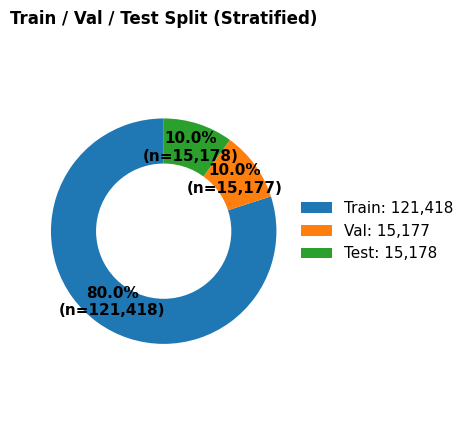

In [14]:
import matplotlib.pyplot as plt

def autopct_count(pct, allvals):
    # show "xx.x%\n(N=12345)"
    count = int(round(pct/100.0 * sum(allvals)))
    return f"{pct:.1f}%\n(n={count:,})"

sizes = [len(X_train), len(X_val), len(X_test)]
labels = ["Train", "Val", "Test"]

fig, ax = plt.subplots(figsize=(4.5, 4.5))

wedges, text_labels, text_pcts = ax.pie(
    sizes,
    labels=None,  # put labels in legend instead
    autopct=lambda pct: autopct_count(pct, sizes),
    startangle=90,
    pctdistance=0.78,   # move % text outward/inward
    labeldistance=1.1,  # only matters if labels!=None
    textprops={"fontsize": 11, "fontweight": "bold"}  # style the % text
)

# donut hole
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
ax.add_artist(centre_circle)

# legend with counts
legend_labels = [f"{name}: {n:,}" for name, n in zip(labels, sizes)]
ax.legend(
    wedges, legend_labels,
    loc="center left", bbox_to_anchor=(1.0, 0.5),
    frameon=False, fontsize=11
)

ax.set_title("Train / Val / Test Split (Stratified)", fontsize=12, fontweight="bold")
ax.axis("equal")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

NUM_CLASSES = len(classes)

def make_mlp(num_classes: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(63,), name="landmarks_63")
    x = tf.keras.layers.Dense(256, activation="relu")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.20)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="probs")(x)
    return tf.keras.Model(inputs, outputs)

model = make_mlp(NUM_CLASSES)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

best_path = "/ssd/SciencePrj25/handpose/models/mlp_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        best_path, monitor="val_acc", mode="max", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_acc", mode="max", patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1,
)

print("Best model saved to:", best_path)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ landmarks_63 (InputLayer)       │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,732 (471.61 KB)

 Trainable params: 119,708 (467.61 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/60


I0000 00:00:1771639437.071102    4884 service.cc:145] XLA service 0xfffe3800ea90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771639437.071189    4884 service.cc:153]   StreamExecutor device (0): Orin, Compute Capability 8.7
I0000 00:00:1771639441.442819    5059 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1716', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1771639441.611861    5060 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1716', 20 bytes spill stores, 20 bytes spill loads

NvMapMemAllocInternalTagged: 1075072515 error 12
NvMapMemHandleAlloc: error 0
NvMapMemAllocInternalTagged: 1075072515 error 12
NvMapMemHandleAlloc: error 0
2026-02-20 20:04:04.685360: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.50MiB with freed_by_count=0.

ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/ssd/SciencePrj25/venv/tf_train/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/ssd/SciencePrj25/venv/tf_train/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/ssd/SciencePrj25/venv/tf_train/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/ssd/SciencePrj25/venv/tf_train/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.10/asyncio/events.py", line 80, in _run

  File "/ssd/SciencePrj25/venv/tf_t

In [10]:
import tensorflow as tf
import json

model_path  = "/ssd/SciencePrj25/handpose/models/mlp_best.keras"
labels_path = "/ssd/SciencePrj25/handpose/models/labels.json"

# 1) Load model
model = tf.keras.models.load_model(model_path)  # loads models saved via model.save() :contentReference[oaicite:0]{index=0}

# 2) Load class names (for confusion matrix labels)
with open(labels_path, "r") as f:
    classes = json.load(f)["classes"]

print("Loaded model:", model_path)
print("Num classes:", len(classes))

Loaded model: /ssd/SciencePrj25/handpose/models/mlp_best.keras
Num classes: 28


N true: 15178 N pred: 15178
accuracy    : 0.99137
f1_macro    : 0.99012
f1_weighted : 0.99138


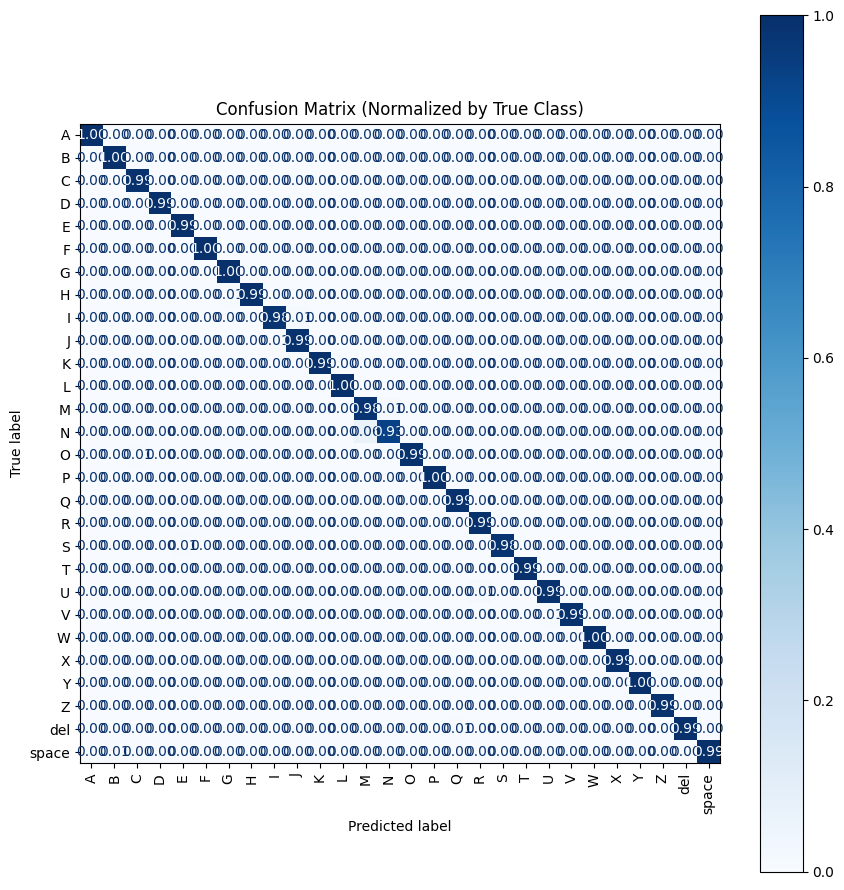

In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict directly on X_test (guaranteed same length)
y_prob = model.predict(X_test, batch_size=512, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# y_test should be shape (N,) with class ids
y_true = y_test.reshape(-1)

print("N true:", y_true.shape[0], "N pred:", y_pred.shape[0])

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print(f"accuracy    : {acc:.5f}")
print(f"f1_macro    : {f1_macro:.5f}")
print(f"f1_weighted : {f1_weighted:.5f}")

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))), normalize="true")

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    ax=ax, cmap="Blues", xticks_rotation=90, values_format=".2f", colorbar=True
)
ax.set_title("Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.savefig("confusion_matrix_norm_true.png", dpi=300)
plt.show()